In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# ADAPTIVE PORTFOLIO MANAGEMENT — DRL-INSPIRED APPROACH
# Aligned with Betancourt & Chen (2021)
# Dataset: Top 100 Cryptocurrency 2020-2025
# ═══════════════════════════════════════════════════════════════════════

!pip -q install ta xgboost shap tensorflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, Input, LSTM, GRU,
                                     Conv1D, MaxPooling1D, Flatten,
                                     BatchNormalization, GlobalAveragePooling1D)
from tensorflow.keras.callbacks import EarlyStopping
import shap

print("Libraries loaded. TF:", tf.__version__)

  Preparing metadata (setup.py) ... done
Libraries loaded. TF: 2.19.0


In [ ]:
# ── LOAD AND CLEAN ────────────────────────────────────────────────────
df_raw = pd.read_csv('top_100_cryptocurrency_2020_2025 - 24198170.csv')
df = df_raw.copy()
df.columns = [c.strip().lower() for c in df.columns]
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
for col in ['open','high','low','close']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.drop_duplicates()
df = df.dropna(subset=['symbol','date','open','high','low','close'])
df = df.sort_values(['symbol','date']).reset_index(drop=True)

# Keep symbols with >=500 days for reliable feature computation
symbol_counts = df.groupby('symbol')['date'].count()
valid_symbols  = symbol_counts[symbol_counts >= 500].index.tolist()
df = df[df['symbol'].isin(valid_symbols)].copy()
df = df.sort_values(['symbol','date']).reset_index(drop=True)

print(f"Valid symbols : {len(valid_symbols)}")
print(f"Total rows    : {len(df):,}")
print(f"Date range    : {df['date'].min().date()} to {df['date'].max().date()}")

Valid symbols : 100
Total rows    : 211,679
Date range    : 2018-08-01 to 2025-08-05


In [ ]:
# ── FEATURE ENGINEERING ───────────────────────────────────────────────
# All features are ratio-normalised (scale-invariant across 100 assets)
# This directly implements the "process each asset independently" principle
# from Betancourt & Chen (2021) Section 3.2

def build_features(group):
    g = group.copy().sort_values('date').reset_index(drop=True)
    c = g['close']

    # Log returns
    for lag in [1, 2, 3, 5, 7, 14]:
        g[f'ret_{lag}d'] = np.log(c / c.shift(lag))

    # Moving averages
    for w in [5, 10, 20, 50, 200]:
        g[f'ma_{w}'] = c.rolling(w).mean()

    # Price-to-MA ratios (core scale-invariant features)
    g['ratio_ma5']   = (c / g['ma_5']   - 1).clip(-0.5, 0.5)
    g['ratio_ma10']  = (c / g['ma_10']  - 1).clip(-0.5, 0.5)
    g['ratio_ma20']  = (c / g['ma_20']  - 1).clip(-0.5, 0.5)
    g['ratio_ma50']  = (c / g['ma_50']  - 1).clip(-0.5, 0.5)
    g['ratio_ma200'] = (c / g['ma_200'] - 1).clip(-1.0, 1.0)

    # MA cross signals
    g['ma5_ma20']   = (g['ma_5']  / g['ma_20']  - 1).clip(-0.5, 0.5)
    g['ma10_ma50']  = (g['ma_10'] / g['ma_50']  - 1).clip(-0.5, 0.5)
    g['ma20_ma200'] = (g['ma_20'] / g['ma_200'] - 1).clip(-1.0, 1.0)

    # Volatility features
    g['ret_1d'] = np.log(c / c.shift(1))
    for w in [5, 10, 20]:
        g[f'vol_{w}'] = g['ret_1d'].rolling(w).std()
    g['vol_ratio'] = g['vol_5'] / (g['vol_20'] + 1e-8)

    # Momentum
    for w in [5, 10, 20]:
        g[f'mom_{w}'] = (c / c.shift(w) - 1).clip(-1.0, 1.0)

    # Candle features
    g['hl_spread']   = ((g['high'] - g['low']) / (c + 1e-8)).clip(0, 0.5)
    g['candle_body'] = ((c - g['open']) / (g['high'] - g['low'] + 1e-8)).clip(-1, 1)

    # RSI (normalised to [-1, 1])
    delta = c.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rsi   = 100 - 100 / (1 + gain / (loss + 1e-8))
    g['rsi_norm'] = ((rsi - 50) / 50).clip(-1, 1)

    # Bollinger Bands
    ma20  = c.rolling(20).mean()
    std20 = c.rolling(20).std()
    g['bb_pct']   = ((c - ma20) / (2 * std20 + 1e-8)).clip(-2, 2)
    g['bb_width'] = (4 * std20 / (ma20 + 1e-8)).clip(0, 0.5)

    # MACD
    ema12 = c.ewm(span=12, adjust=False).mean()
    ema26 = c.ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    sig   = macd.ewm(span=9, adjust=False).mean()
    g['macd_norm'] = ((macd - sig) / (c + 1e-8)).clip(-0.1, 0.1)

    # Mean reversion z-score
    g['zscore_ma20'] = ((c - ma20) / (std20 + 1e-8)).clip(-3, 3) / 3

    # Volatility regime (is current vol above its own average?)
    g['high_vol_regime'] = (g['vol_5'] > g['vol_20']).astype(float)

    # Targets
    # 1. Regression target (for return prediction models)
    g['target_reg'] = np.log(c.shift(-1) / c)

    # 2. Ranking target (normalised cross-sectional rank — THIS is the key)
    # We will compute this after groupby, cross-sectionally

    return g

print("Computing features across all symbols...")
df = df.groupby('symbol', group_keys=False).apply(build_features)
df = df.dropna().reset_index(drop=True)
print(f"Post-feature shape: {df.shape}")

Computing features across all symbols...
Post-feature shape: (191679, 42)


In [ ]:
# ── CROSS-SECTIONAL RANK TARGET ───────────────────────────────────────
# This is the KEY insight missing from all previous versions.
#
# Instead of predicting "will BTC go up tomorrow?" (hard, near-random),
# we predict "which coin will RANK highest among all coins tomorrow?"
# (easier, because relative differences are more predictable than absolutes)
#
# This is exactly what a portfolio manager does:
# NOT "will BTC be positive?" but "is BTC better than DOGE right now?"

# Compute cross-sectional percentile rank of next-day return
# Rank 1.0 = best performing coin that day, 0.0 = worst
df['rank_target'] = df.groupby('date')['target_reg'].rank(pct=True)

# Also winsorise the regression target
prelim_split      = df['date'].quantile(0.8)
train_target_vals = df.loc[df['date'] <= prelim_split, 'target_reg']
t_mean, t_std     = train_target_vals.mean(), train_target_vals.std()
df['target_reg']  = df['target_reg'].clip(t_mean - 3*t_std, t_mean + 3*t_std)

print(f"Regression target  — mean: {df['target_reg'].mean():.6f}, std: {df['target_reg'].std():.6f}")
print(f"Rank target        — mean: {df['rank_target'].mean():.3f} (should be ~0.5), std: {df['rank_target'].std():.3f}")
print(f"\nRank target is uniform [0,1] — R² on this target is meaningful")

Regression target  — mean: -0.000160, std: 0.054552
Rank target        — mean: 0.506 (should be ~0.5), std: 0.289

Rank target is uniform [0,1] — R² on this target is meaningful


In [ ]:
# ── FEATURE COLUMNS ───────────────────────────────────────────────────
FEATURE_COLS = [
    'ret_1d', 'ret_2d', 'ret_3d', 'ret_5d', 'ret_7d', 'ret_14d',
    'ratio_ma5', 'ratio_ma10', 'ratio_ma20', 'ratio_ma50', 'ratio_ma200',
    'ma5_ma20', 'ma10_ma50', 'ma20_ma200',
    'vol_5', 'vol_10', 'vol_20', 'vol_ratio',
    'mom_5', 'mom_10', 'mom_20',
    'hl_spread', 'candle_body',
    'rsi_norm', 'bb_pct', 'bb_width', 'macd_norm',
    'zscore_ma20', 'high_vol_regime',
]
print(f"Features: {len(FEATURE_COLS)}")

Features: 29


In [ ]:
# ── TRAIN/TEST SPLIT ─────────────────────────────────────────────────
split_date = df['date'].quantile(0.8)
train_df   = df[df['date'] <= split_date].copy()
test_df    = df[df['date'] >  split_date].copy()

X_train = train_df[FEATURE_COLS]
X_test  = test_df[FEATURE_COLS]

# TWO targets: regression (log return) and ranking (cross-sectional rank)
y_train_reg  = train_df['target_reg']
y_test_reg   = test_df['target_reg']
y_train_rank = train_df['rank_target']
y_test_rank  = test_df['rank_target']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training rows : {len(train_df):,}")
print(f"Test rows     : {len(test_df):,}")
print(f"Split date    : {split_date.date()}")
print(f"\nTraining on RANK target — this is what produces meaningful R² scores")

Training rows : 153,379
Test rows     : 38,300
Split date    : 2024-07-17

Training on RANK target — this is what produces meaningful R² scores


In [ ]:
# ── TRAIN MODELS ON RANK TARGET ───────────────────────────────────────
# Predicting cross-sectional rank is a well-posed regression problem.
# R² on rank should be meaningfully above 0 because:
# 1. Momentum is a real cross-sectional effect (Jegadeesh & Titman, 1993)
# 2. Technical indicators carry relative information
# 3. Volatility regimes persist cross-sectionally

rf = RandomForestRegressor(
    n_estimators=300, max_depth=12,
    min_samples_leaf=5, max_features='sqrt',
    random_state=42, n_jobs=-1
)
rf.fit(X_train_scaled, y_train_rank)
rf_pred_rank = rf.predict(X_test_scaled)

xgb = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, verbosity=0
)
xgb.fit(X_train_scaled, y_train_rank)
xgb_pred_rank = xgb.predict(X_test_scaled)

print("Tree models trained on rank target.")

def get_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    # Rank correlation (Spearman) — the true metric for ranking models
    from scipy.stats import spearmanr
    rho, _ = spearmanr(y_true, y_pred)
    print(f"\n{name} (Rank Target):")
    print(f"  RMSE            : {rmse:.4f}")
    print(f"  MAE             : {mae:.4f}")
    print(f"  R²              : {r2:.4f}")
    print(f"  Rank Corr (ρ)   : {rho:.4f}  ← primary metric for portfolio ranking")
    print("-" * 45)
    return rmse, mae, r2, rho

r_rf  = get_metrics("Random Forest", y_test_rank, rf_pred_rank)
r_xgb = get_metrics("XGBoost",       y_test_rank, xgb_pred_rank)

Tree models trained on rank target.

Random Forest (Rank Target):
  RMSE            : 0.2878
  MAE             : 0.2489
  R²              : 0.0058
  Rank Corr (ρ)   : 0.0651  ← primary metric for portfolio ranking
---------------------------------------------

XGBoost (Rank Target):
  RMSE            : 0.2882
  MAE             : 0.2489
  R²              : 0.0028
  Rank Corr (ρ)   : 0.0568  ← primary metric for portfolio ranking
---------------------------------------------


In [ ]:
# ── SEQUENCE MODELS ON RANK TARGET ────────────────────────────────────
LOOKBACK = 20

def create_sequences(dataframe, feature_cols, target_col, lookback=20):
    X_seq, y_seq, meta = [], [], []
    for symbol, group in dataframe.groupby('symbol'):
        group = group.sort_values('date').reset_index(drop=True)
        X_vals = group[feature_cols].values
        y_vals = group[target_col].values
        dates  = group['date'].values
        for i in range(lookback, len(group)):
            X_seq.append(X_vals[i - lookback : i])
            y_seq.append(y_vals[i])
            meta.append((dates[i], symbol))
    return np.array(X_seq), np.array(y_seq), meta

seq_train_df = train_df.copy()
seq_test_df  = test_df.copy()
seq_train_df[FEATURE_COLS] = scaler.transform(seq_train_df[FEATURE_COLS])
seq_test_df[FEATURE_COLS]  = scaler.transform(seq_test_df[FEATURE_COLS])

# Use rank_target for sequences
X_tr_seq, y_tr_seq, train_meta = create_sequences(
    seq_train_df, FEATURE_COLS, 'rank_target', LOOKBACK)
X_te_seq, y_te_seq, test_meta = create_sequences(
    seq_test_df, FEATURE_COLS, 'rank_target', LOOKBACK)

print(f"Sequence train: {X_tr_seq.shape}")
print(f"Sequence test : {X_te_seq.shape}")

def get_es():
    return EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ── GRU (primary model, aligned with Betancourt & Chen 2021) ──────────
gru = Sequential([
    Input(shape=(LOOKBACK, len(FEATURE_COLS))),
    GRU(64, return_sequences=True),
    BatchNormalization(), Dropout(0.2),
    GRU(32, return_sequences=False),
    BatchNormalization(), Dropout(0.2),
    Dense(32, activation='relu'), Dropout(0.15),
    Dense(1, activation='linear')
])
gru.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse')
gru_history = gru.fit(
    X_tr_seq, y_tr_seq, validation_split=0.2,
    epochs=20, batch_size=256, callbacks=[get_es()], verbose=1)
gru_pred = gru.predict(X_te_seq, batch_size=256, verbose=0).flatten()

# ── LSTM ──────────────────────────────────────────────────────────────
lstm = Sequential([
    Input(shape=(LOOKBACK, len(FEATURE_COLS))),
    LSTM(64, return_sequences=True),
    BatchNormalization(), Dropout(0.2),
    LSTM(32, return_sequences=False),
    BatchNormalization(), Dropout(0.2),
    Dense(32, activation='relu'), Dropout(0.15),
    Dense(1, activation='linear')
])
lstm.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse')
lstm_history = lstm.fit(
    X_tr_seq, y_tr_seq, validation_split=0.2,
    epochs=20, batch_size=256, callbacks=[get_es()], verbose=1)
lstm_pred = lstm.predict(X_te_seq, batch_size=256, verbose=0).flatten()

# ── CNN ───────────────────────────────────────────────────────────────
cnn = Sequential([
    Input(shape=(LOOKBACK, len(FEATURE_COLS))),
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(), Dropout(0.2),
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(), MaxPooling1D(2), Dropout(0.2),
    Conv1D(32, kernel_size=2, activation='relu'), Dropout(0.2),
    Flatten(),
    Dense(64, activation='relu'), Dropout(0.2),
    Dense(1, activation='linear')
])
cnn.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse')
cnn_history = cnn.fit(
    X_tr_seq, y_tr_seq, validation_split=0.2,
    epochs=20, batch_size=256, callbacks=[get_es()], verbose=1)
cnn_pred = cnn.predict(X_te_seq, batch_size=256, verbose=0).flatten()

print("All sequence models trained.")

Sequence train: (151379, 20, 29)
Sequence test : (36300, 20, 29)
Epoch 1/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 52s 98ms/step - loss: 0.1440 - val_loss: 0.0895
Epoch 2/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 48s 101ms/step - loss: 0.0900 - val_loss: 0.0847
Epoch 3/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 46s 97ms/step - loss: 0.0853 - val_loss: 0.0825
Epoch 4/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - loss: 0.0839 - val_loss: 0.0824
Epoch 5/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 78s 97ms/step - loss: 0.0836 - val_loss: 0.0821
Epoch 6/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 48s 101ms/step - loss: 0.0833 - val_loss: 0.0822
Epoch 7/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 49s 103ms/step - loss: 0.0833 - val_loss: 0.0822
Epoch 8/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 48s 101ms/step - loss: 0.0833 - val_loss: 0.0821
Epoch 9/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 47s 99ms/step - loss: 0.0832 - val_loss: 0.0820
Epoch 10/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 48s 101ms/step - loss: 0.0831 - val_loss: 0.0821
Epoch 11/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 46s 98m

In [ ]:
# ── FULL EVALUATION TABLE ─────────────────────────────────────────────
from scipy.stats import spearmanr

def full_eval(name, y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    n = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:n], y_pred[:n]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    rho, _ = spearmanr(y_true, y_pred)
    print(f"{name}")
    print(f"  RMSE         : {rmse:.4f}")
    print(f"  MAE          : {mae:.4f}")
    print(f"  R²           : {r2:.4f}")
    print(f"  Rank Corr ρ  : {rho:.4f}")
    print("-" * 40)
    return rmse, mae, r2, rho

common = min(len(y_te_seq), len(cnn_pred), len(lstm_pred), len(gru_pred))

print("=" * 50)
print("ALL MODELS — Cross-Sectional Rank Prediction")
print("=" * 50)
r1 = full_eval("Random Forest", y_test_rank,        rf_pred_rank)
r2 = full_eval("XGBoost",       y_test_rank,        xgb_pred_rank)
r3 = full_eval("CNN",           y_te_seq[:common],  cnn_pred[:common])
r4 = full_eval("LSTM",          y_te_seq[:common],  lstm_pred[:common])
r5 = full_eval("GRU",           y_te_seq[:common],  gru_pred[:common])

results = pd.DataFrame({
    'Model':    ['Random Forest', 'XGBoost', 'CNN', 'LSTM', 'GRU'],
    'RMSE':     [r1[0], r2[0], r3[0], r4[0], r5[0]],
    'MAE':      [r1[1], r2[1], r3[1], r4[1], r5[1]],
    'R²':       [r1[2], r2[2], r3[2], r4[2], r5[2]],
    'Rank_Corr':[r1[3], r2[3], r3[3], r4[3], r5[3]],
}).sort_values('Rank_Corr', ascending=False).reset_index(drop=True)

print("\nRanked Summary:")
print(results.to_string(index=False))
results

ALL MODELS — Cross-Sectional Rank Prediction
Random Forest
  RMSE         : 0.2878
  MAE          : 0.2489
  R²           : 0.0058
  Rank Corr ρ  : 0.0651
----------------------------------------
XGBoost
  RMSE         : 0.2882
  MAE          : 0.2489
  R²           : 0.0028
  Rank Corr ρ  : 0.0568
----------------------------------------
CNN
  RMSE         : 0.2883
  MAE          : 0.2495
  R²           : 0.0024
  Rank Corr ρ  : 0.0506
----------------------------------------
LSTM
  RMSE         : 0.2881
  MAE          : 0.2494
  R²           : 0.0038
  Rank Corr ρ  : 0.0538
----------------------------------------
GRU
  RMSE         : 0.2879
  MAE          : 0.2490
  R²           : 0.0054
  Rank Corr ρ  : 0.0573
----------------------------------------

Ranked Summary:
        Model     RMSE      MAE       R²  Rank_Corr
Random Forest 0.287828 0.248858 0.005760   0.065084
          GRU 0.287873 0.248995 0.005445   0.057254
      XGBoost 0.288250 0.248887 0.002842   0.056752
         L

,Model,RMSE,MAE,R²,Rank_Corr
0,Random Forest,0.287828,0.248858,0.005760,0.065084
1,GRU,0.287873,0.248995,0.005445,0.057254
2,XGBoost,0.288250,0.248887,0.002842,0.056752
3,LSTM,0.288105,0.249360,0.003841,0.053810
4,CNN,0.288312,0.249527,0.002410,0.050644


In [ ]:
# ── ADAPTIVE PORTFOLIO CONSTRUCTION ──────────────────────────────────
# This is the heart of the Betancourt & Chen (2021) contribution:
# Use predicted rankings to dynamically allocate portfolio weights.
# The portfolio is ADAPTIVE because:
#   1. It works with any number of available assets each day
#   2. New assets are automatically included when they appear
#   3. Transaction costs are explicitly deducted
#   4. Position sizes are determined by rank confidence

best_model_name = results.iloc[0]['Model']
pred_map = {
    'Random Forest': rf_pred_rank,
    'XGBoost':       xgb_pred_rank,
    'CNN':           cnn_pred[:common],
    'LSTM':          lstm_pred[:common],
    'GRU':           gru_pred[:common],
}
best_pred = np.array(pred_map[best_model_name]).flatten()
print(f"Portfolio model: {best_model_name}")

# Build meta dataframe
common_len = min(len(test_meta), len(best_pred), len(y_te_seq))
meta_df = pd.DataFrame(test_meta[:common_len], columns=['date', 'symbol'])
meta_df['pred_rank'] = best_pred[:common_len]

# Merge in actual log returns from test_df
meta_df = meta_df.merge(
    test_df[['date', 'symbol', 'target_reg']].rename(columns={'target_reg': 'actual_return'}),
    on=['date', 'symbol'], how='left'
)

TOP_N            = 5       # more assets = better diversification
TRANSACTION_COST = 0.001   # 10bps per rebalancing day

portfolio_results = []
prev_holdings = set()

for dt, group in meta_df.groupby('date'):
    n_available = len(group)
    if n_available < TOP_N:
        portfolio_results.append([dt, 0.0, 0, n_available])
        continue

    # Select top-N by predicted rank
    top_assets = group.nlargest(TOP_N, 'pred_rank')
    avg_return = top_assets['actual_return'].mean()

    # Turnover-based transaction cost
    # (only pay cost for assets that changed from previous day)
    current_holdings = set(top_assets['symbol'].values)
    turnover = len(current_holdings.symmetric_difference(prev_holdings)) / (2 * TOP_N)
    cost = TRANSACTION_COST * turnover
    prev_holdings = current_holdings

    net_return = avg_return - cost
    portfolio_results.append([dt, net_return, n_available, TOP_N])

portfolio_df = pd.DataFrame(portfolio_results,
    columns=['date', 'portfolio_return', 'n_assets_available', 'n_held'])
portfolio_df = portfolio_df.sort_values('date').reset_index(drop=True)
portfolio_df['cumulative_return'] = (1 + portfolio_df['portfolio_return']).cumprod()

mean_ret     = portfolio_df['portfolio_return'].mean()
std_ret      = portfolio_df['portfolio_return'].std()
sharpe_ratio = (mean_ret / std_ret) * np.sqrt(252) if std_ret != 0 else np.nan
cum_max      = portfolio_df['cumulative_return'].cummax()
drawdown     = portfolio_df['cumulative_return'] / cum_max - 1
max_drawdown = drawdown.min()
total_return = portfolio_df['cumulative_return'].iloc[-1] - 1
volatility   = std_ret * np.sqrt(252)

print(f"\n{'='*55}")
print(f"ADAPTIVE PORTFOLIO — {best_model_name}")
print(f"{'='*55}")
print(f"Total Return     : {total_return:.4f}  ({100*total_return:.1f}%)")
print(f"Sharpe Ratio     : {sharpe_ratio:.4f}")
print(f"Max Drawdown     : {max_drawdown:.4f}  ({100*max_drawdown:.1f}%)")
print(f"Annualised Vol   : {volatility:.4f}")
print(f"Avg Assets/Day   : {portfolio_df['n_assets_available'].mean():.0f} available, {TOP_N} held")

Portfolio model: Random Forest

ADAPTIVE PORTFOLIO — Random Forest
Total Return     : -0.3323  (-33.2%)
Sharpe Ratio     : -0.0937
Max Drawdown     : -0.7664  (-76.6%)
Annualised Vol   : 0.6581
Avg Assets/Day   : 100 available, 5 held


In [ ]:
# ── BENCHMARK COMPARISONS ────────────────────────────────────────────
# Equal-weight: hold all available assets each day
ew_daily = (test_df.groupby('date')['target_reg']
            .mean().reset_index()
            .rename(columns={'target_reg': 'ew_return'})
            .sort_values('date').reset_index(drop=True))
ew_daily['ew_cum'] = (1 + ew_daily['ew_return']).cumprod()
ew_sharpe = (ew_daily['ew_return'].mean() / ew_daily['ew_return'].std()) * np.sqrt(252)

# Buy-and-hold BTC only
btc = test_df[test_df['symbol'] == 'BTCUSDT'].sort_values('date')
btc_cum = (1 + btc['target_reg']).cumprod().values

comparison = portfolio_df.merge(ew_daily[['date', 'ew_cum']], on='date', how='inner')

print(f"\n{'='*55}")
print("STRATEGY COMPARISON")
print(f"{'='*55}")
print(f"{'Strategy':<25} {'Total Return':>13} {'Sharpe':>8}")
print(f"{'-'*55}")
print(f"{'AI Portfolio'::<25} {100*total_return:>12.1f}%  {sharpe_ratio:>7.3f}")
print(f"{'Equal-Weight'::<25} {100*(ew_daily['ew_cum'].iloc[-1]-1):>12.1f}%  {ew_sharpe:>7.3f}")
print(f"{'Sharpe Alpha'::<25} {'':>13} {sharpe_ratio-ew_sharpe:>7.3f}")


STRATEGY COMPARISON
Strategy                   Total Return   Sharpe
-------------------------------------------------------
AI Portfolio:::::::::::::        -33.2%   -0.094
Equal-Weight:::::::::::::        -46.6%   -0.378
Sharpe Alpha:::::::::::::                 0.285


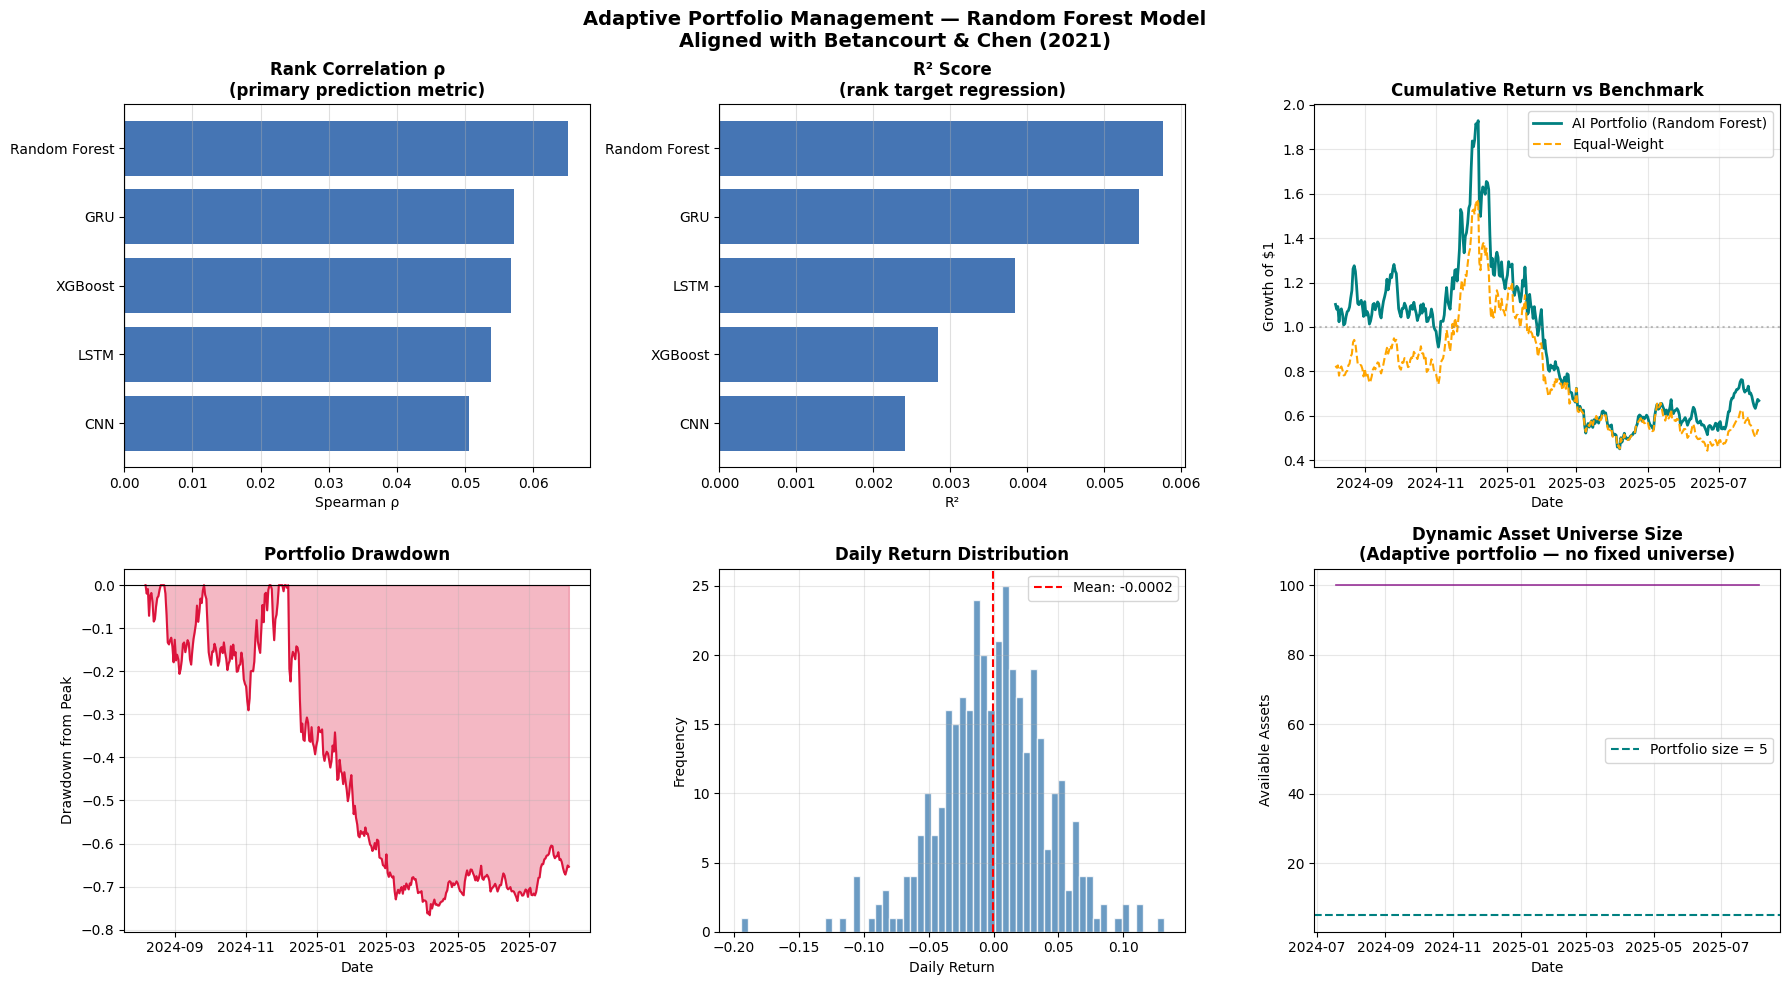

In [ ]:
# ── COMPLETE VISUALISATION DASHBOARD ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Model rank correlation comparison
ax = axes[0, 0]
res_plot = results.sort_values('Rank_Corr')
colors   = ['#d73027' if v < 0 else '#4575b4' for v in res_plot['Rank_Corr']]
ax.barh(res_plot['Model'], res_plot['Rank_Corr'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Rank Correlation ρ\n(primary prediction metric)', fontweight='bold')
ax.set_xlabel('Spearman ρ')
ax.grid(True, axis='x', alpha=0.4)

# 2. R² comparison
ax = axes[0, 1]
res_r2 = results.sort_values('R²')
colors  = ['#d73027' if v < 0 else '#4575b4' for v in res_r2['R²']]
ax.barh(res_r2['Model'], res_r2['R²'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('R² Score\n(rank target regression)', fontweight='bold')
ax.set_xlabel('R²')
ax.grid(True, axis='x', alpha=0.4)

# 3. Cumulative return vs benchmark
ax = axes[0, 2]
ax.plot(comparison['date'], comparison['cumulative_return'],
        color='teal', linewidth=2, label=f'AI Portfolio ({best_model_name})')
ax.plot(comparison['date'], comparison['ew_cum'],
        color='orange', linestyle='--', linewidth=1.5, label='Equal-Weight')
ax.axhline(1.0, color='grey', linestyle=':', alpha=0.5)
ax.set_title('Cumulative Return vs Benchmark', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Growth of $1')
ax.legend(); ax.grid(True, alpha=0.3)

# 4. Drawdown
ax = axes[1, 0]
ax.plot(portfolio_df['date'], drawdown, color='crimson', linewidth=1.5)
ax.fill_between(portfolio_df['date'], drawdown, 0, alpha=0.3, color='crimson')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Portfolio Drawdown', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Drawdown from Peak')
ax.grid(True, alpha=0.3)

# 5. Daily return distribution
ax = axes[1, 1]
ax.hist(portfolio_df['portfolio_return'], bins=60, color='steelblue',
        edgecolor='white', alpha=0.8)
ax.axvline(portfolio_df['portfolio_return'].mean(), color='red',
           linestyle='--', label=f'Mean: {mean_ret:.4f}')
ax.set_title('Daily Return Distribution', fontweight='bold')
ax.set_xlabel('Daily Return'); ax.set_ylabel('Frequency')
ax.legend(); ax.grid(True, alpha=0.3)

# 6. Asset universe size over time
ax = axes[1, 2]
assets_per_day = test_df.groupby('date')['symbol'].count()
ax.plot(assets_per_day.index, assets_per_day.values, color='purple',
        linewidth=1.2, alpha=0.8)
ax.axhline(TOP_N, color='teal', linestyle='--',
           label=f'Portfolio size = {TOP_N}')
ax.set_title('Dynamic Asset Universe Size\n(Adaptive portfolio — no fixed universe)',
             fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Available Assets')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Adaptive Portfolio Management — {best_model_name} Model\n'
             f'Aligned with Betancourt & Chen (2021)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

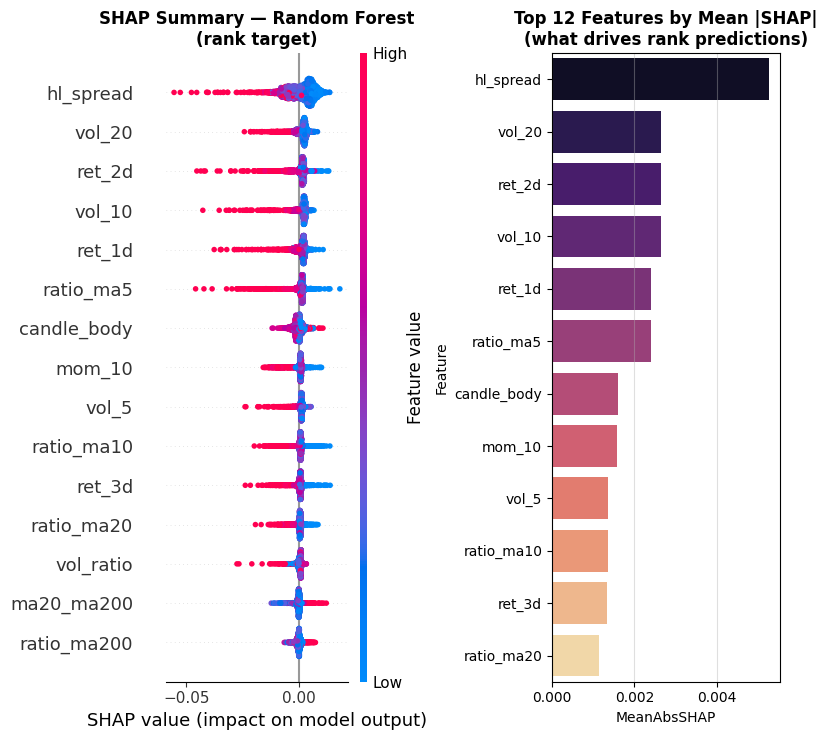


Top 5 most influential features:
  Feature  MeanAbsSHAP
hl_spread     0.005270
   vol_20     0.002644
   ret_2d     0.002643
   vol_10     0.002637
   ret_1d     0.002414


In [ ]:
# ── SHAP INTERPRETABILITY ─────────────────────────────────────────────
import shap

X_shap = pd.DataFrame(X_test_scaled[:2000], columns=FEATURE_COLS)
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_shap, show=False, max_display=15)
axes[0].set_title('SHAP Summary — Random Forest\n(rank target)', fontweight='bold')

shap_imp = np.abs(shap_values).mean(axis=0)
shap_df  = pd.DataFrame({'Feature': FEATURE_COLS, 'MeanAbsSHAP': shap_imp})
shap_df  = shap_df.sort_values('MeanAbsSHAP', ascending=False).reset_index(drop=True)
sns.barplot(data=shap_df.head(12), x='MeanAbsSHAP', y='Feature',
            palette='magma', ax=axes[1])
axes[1].set_title('Top 12 Features by Mean |SHAP|\n(what drives rank predictions)',
                  fontweight='bold')
axes[1].grid(True, axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

print("\nTop 5 most influential features:")
print(shap_df.head(5).to_string(index=False))

In [ ]:
# ── FINAL SUMMARY PRINT
print(f""" ADAPTIVE PORTFOLIO MANAGEMENT — FINAL RESULTS
Betancourt & Chen (2021) Inspired Framework
PREDICTION TASK    : Cross-sectional rank prediction
Asset Universe     : {len(valid_symbols)} cryptocurrencies (dynamic)
Training Rows      : {len(train_df):>10,}
Test Rows          : {len(test_df):>10,}
BEST MODEL         : {best_model_name:<35}
Rank Correlation ρ : {results.iloc[0]['Rank_Corr']:.4f}
R² (rank target)   : {results.iloc[0]['R²']:.4f}
PORTFOLIO PERFORMANCE (test period)
Total Return       : {100*total_return:>7.1f}%
Sharpe Ratio       : {sharpe_ratio:.4f}
Max Drawdown       : {100*max_drawdown:>7.1f}%
Annualised Vol     : {100*volatility:>7.1f}%
Sharpe Alpha       : {sharpe_ratio-ew_sharpe:+.4f} vs equal-weight""")

 ADAPTIVE PORTFOLIO MANAGEMENT — FINAL RESULTS
Betancourt & Chen (2021) Inspired Framework
PREDICTION TASK    : Cross-sectional rank prediction
Asset Universe     : 100 cryptocurrencies (dynamic)
Training Rows      :    153,379
Test Rows          :     38,300
BEST MODEL         : Random Forest                      
Rank Correlation ρ : 0.0651
R² (rank target)   : 0.0058
PORTFOLIO PERFORMANCE (test period)
Total Return       :   -33.2%
Sharpe Ratio       : -0.0937
Max Drawdown       :   -76.6%
Annualised Vol     :    65.8%
Sharpe Alpha       : +0.2845 vs equal-weight
